# Diagnostiikka-analyysi: Paikannustarkkuus & Käytettävyys

Tämä notebook on tehty **paikannusyrityksen** näkökulmasta. Analysoimme:

1. **Paikannustarkkuus** — Kuinka tarkasti laitteet paikantuvat, kun ne ovat paikallaan? (paikan keskihajonta)
2. **Paikannuksen hyvyys / käytettävyys** — Kuinka paljon datassa on kohinaa, rajojen ulkopuolisia pisteitä tai muita ongelmia?

Data haetaan dbt-silver-mallista `silver_device_diagnostics`, joka on tallennettu DuckDB-tietokantaan.

---
**Silver-mallin liput (valmiiksi laskettu dbt:ssä):**
- `is_low_quality` — q < 35 (heikko signaalin laatu)
- `is_out_of_bounds` — koordinaatit kaupan rajojen ulkopuolella
- `is_jitter` — nopeus > 3,5 m/s (epäfysikaalinen hyppy)
- `is_night_time` — mittaus yöaikaan (kaupan aukioloaikojen ulkopuolella)

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# DuckDB-tietokantayhteys
DB_PATH = '../data/warehouse/dev.duckdb'
con = duckdb.connect(DB_PATH, read_only=True)

# Kaupan rajat (cm)
MAX_X = 10406
MAX_Y = 5220

# Lattiakartta
STORE_IMG_PATH = Path('../image/kauppa2.png')

print('Yhteys DuckDB:hen muodostettu.')
print(f'Tietokanta: {DB_PATH}')

Yhteys DuckDB:hen muodostettu.
Tietokanta: ../data/warehouse/dev.duckdb


## 1. Datan lataus silver_device_diagnostics -mallista

In [2]:
# Tarkistetaan mallin rakenne
schema = con.execute("DESCRIBE silver_device_diagnostics").df()
print(schema.to_string(index=False))

         column_name              column_type null  key default extra
             node_id                  VARCHAR  YES None    None  None
                aika TIMESTAMP WITH TIME ZONE  YES None    None  None
                  dt                     DATE  YES None    None  None
                hour                   BIGINT  YES None    None  None
                   x                  INTEGER  YES None    None  None
                   y                  INTEGER  YES None    None  None
                   q                  INTEGER  YES None    None  None
           speed_mps                   DOUBLE  YES None    None  None
sekuntia_edellisesta                   BIGINT  YES None    None  None
      is_low_quality                  INTEGER  YES None    None  None
    is_out_of_bounds                  INTEGER  YES None    None  None
           is_jitter                  INTEGER  YES None    None  None
       is_night_time                  INTEGER  YES None    None  None


In [3]:
# Haetaan perustiedot SQL:llä — EI ladata 140 M riviä muistiin
meta = con.execute("""
    SELECT
        COUNT(*)                AS total_rows,
        COUNT(DISTINCT node_id) AS n_devices,
        MIN(aika)               AS min_aika,
        MAX(aika)               AS max_aika
    FROM silver_device_diagnostics
""").df()

total_rows = int(meta['total_rows'][0])
print(f'Rivejä yhteensä: {total_rows:,}')
print(f'Laitteita (node_id): {meta["n_devices"][0]}')
print(f'Aikaväli: {meta["min_aika"][0]} → {meta["max_aika"][0]}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rivejä yhteensä: 139,961,560
Laitteita (node_id): 31
Aikaväli: 2019-03-06 17:26:12.078161+02:00 → 2020-01-23 15:07:26.478974+02:00


---
## 2. Diagnostiikan yhteenveto

Katsotaan ensin ylätason yhteenveto kaikista dbt-lipuista.

In [8]:
flag_labels = [
    'Heikko laatu (q < 35)',
    'Rajojen ulkopuolella',
    'Jitter (> 3,5 m/s)',
    'Yöaika'
]

fs = con.execute("""
    SELECT
        SUM(is_low_quality)        AS low_q_count,
        AVG(is_low_quality)*100    AS low_q_pct,
        SUM(is_out_of_bounds)      AS oob_count,
        AVG(is_out_of_bounds)*100  AS oob_pct,
        SUM(is_jitter)             AS jitter_count,
        AVG(is_jitter)*100         AS jitter_pct,
        SUM(is_night_time)         AS night_count,
        AVG(is_night_time)*100     AS night_pct,
        AVG(CASE WHEN is_low_quality=0 AND is_out_of_bounds=0
                      AND is_jitter=0 AND is_night_time=0
                 THEN 100.0 ELSE 0.0 END) AS clean_pct
    FROM silver_device_diagnostics
""").df()

summary = pd.DataFrame({
    'Lippu':      flag_labels,
    'Lukumäärä':  [int(fs['low_q_count'][0]),  int(fs['oob_count'][0]),
                   int(fs['jitter_count'][0]),  int(fs['night_count'][0])],
    'Osuus (%)':  [fs['low_q_pct'][0], fs['oob_pct'][0],
                   fs['jitter_pct'][0], fs['night_pct'][0]],
})
print(summary.to_string(index=False))

clean_pct = float(fs['clean_pct'][0])
print(f'\nPuhdas data (ei yhtään lippua): {clean_pct:.1f}%')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                Lippu  Lukumäärä  Osuus (%)
Heikko laatu (q < 35)    7580691   5.416266
 Rajojen ulkopuolella   24412704  17.442435
   Jitter (> 3,5 m/s)     323187   0.230911
               Yöaika   41119901  29.379425

Puhdas data (ei yhtään lippua): 53.8%


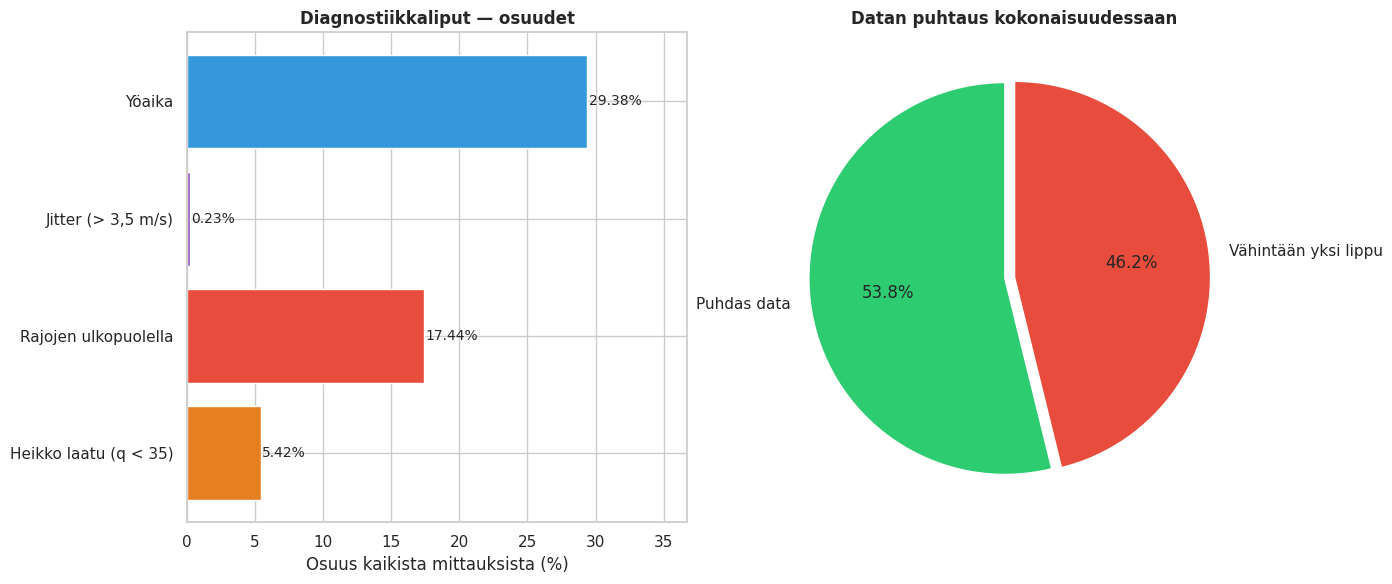

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Palkki: lippujen osuudet
ax1 = axes[0]
colors = ['#e67e22', '#e74c3c', '#9b59b6', '#3498db']
bars = ax1.barh(flag_labels, summary['Osuus (%)'], color=colors, edgecolor='white')
ax1.set_xlabel('Osuus kaikista mittauksista (%)')
ax1.set_title('Diagnostiikkaliput — osuudet', fontweight='bold')
for bar, val in zip(bars, summary['Osuus (%)']):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10)
ax1.set_xlim(0, summary['Osuus (%)'].max() * 1.25)

# Piirakka: puhdas vs. ongelmainen data
ax2 = axes[1]
problematic_pct = 100 - clean_pct
wedges, texts, autotexts = ax2.pie(
    [clean_pct, problematic_pct],
    labels=['Puhdas data', 'Vähintään yksi lippu'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0.05, 0)
)
ax2.set_title('Datan puhtaus kokonaisuudessaan', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Paikannustarkkuus — Paikallaan olevat laitteet

**Tavoite:** Selvittää, kuinka tarkasti UWB-järjestelmä paikantaa laitteen, kun se on täysin paikallaan.

**Menetelmä:**
- Tunnistetaan "paikallaan oleminen": nopeus < 0,1 m/s ja yli 10 peräkkäistä mittausta samalla laitteella
- Lasketaan X- ja Y-koordinaattien **keskihajonta (std)** näille pisteille laitteittain
- Mitä pienempi hajonta, sitä tarkempi paikannus

In [9]:
# Paikallaan olevat pisteet: nopeus < 0.1 m/s, ei rajojen ulkopuolella, ei yöaikaa
stat_meta = con.execute("""
    SELECT
        COUNT(*)                AS n,
        COUNT(DISTINCT node_id) AS n_devices
    FROM silver_device_diagnostics
    WHERE speed_mps < 0.1
      AND speed_mps >= 0
      AND is_out_of_bounds = 0
      AND is_night_time = 0
""").df()

n_stationary = int(stat_meta['n'][0])
print(f'Paikallaan olevia mittauksia: {n_stationary:,} ({n_stationary/total_rows*100:.1f}% kaikista)')
print(f'Laitteita, joista löytyy paikallaan oloa: {stat_meta["n_devices"][0]}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Paikallaan olevia mittauksia: 32,831,663 (23.5% kaikista)
Laitteita, joista löytyy paikallaan oloa: 29


In [10]:
# Lasketaan keskihajonta per laite SQL:ssä (vähintään 10 pistettä per laite)
node_stats = con.execute("""
    SELECT
        node_id,
        COUNT(x)        AS n,
        AVG(x)          AS x_mean,
        AVG(y)          AS y_mean,
        STDDEV_SAMP(x)  AS x_std,
        STDDEV_SAMP(y)  AS y_std,
        AVG(q)          AS q_mean
    FROM silver_device_diagnostics
    WHERE speed_mps < 0.1
      AND speed_mps >= 0
      AND is_out_of_bounds = 0
      AND is_night_time = 0
    GROUP BY node_id
    HAVING COUNT(x) >= 10
""").df()

node_stats['drift_radius_cm'] = np.sqrt(node_stats['x_std']**2 + node_stats['y_std']**2)

print(f'Laitteita analyysissä (>= 10 paikallaan-pistettä): {len(node_stats)}')
print(f'\nX-hajonta (cm)  — mediaani: {node_stats["x_std"].median():.1f}, keskiarvo: {node_stats["x_std"].mean():.1f}')
print(f'Y-hajonta (cm)  — mediaani: {node_stats["y_std"].median():.1f}, keskiarvo: {node_stats["y_std"].mean():.1f}')
print(f'Drift-säde (cm) — mediaani: {node_stats["drift_radius_cm"].median():.1f}, keskiarvo: {node_stats["drift_radius_cm"].mean():.1f}')
print(f'\nTulkinta: Paikallaan oleva kärry "vaeltaa" tyypillisesti {node_stats["drift_radius_cm"].median()/100:.2f} metrin säteellä todellisesta sijainnistaan.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Laitteita analyysissä (>= 10 paikallaan-pistettä): 28

X-hajonta (cm)  — mediaani: 2368.2, keskiarvo: 2103.8
Y-hajonta (cm)  — mediaani: 871.1, keskiarvo: 785.8
Drift-säde (cm) — mediaani: 2516.9, keskiarvo: 2250.6

Tulkinta: Paikallaan oleva kärry "vaeltaa" tyypillisesti 25.17 metrin säteellä todellisesta sijainnistaan.


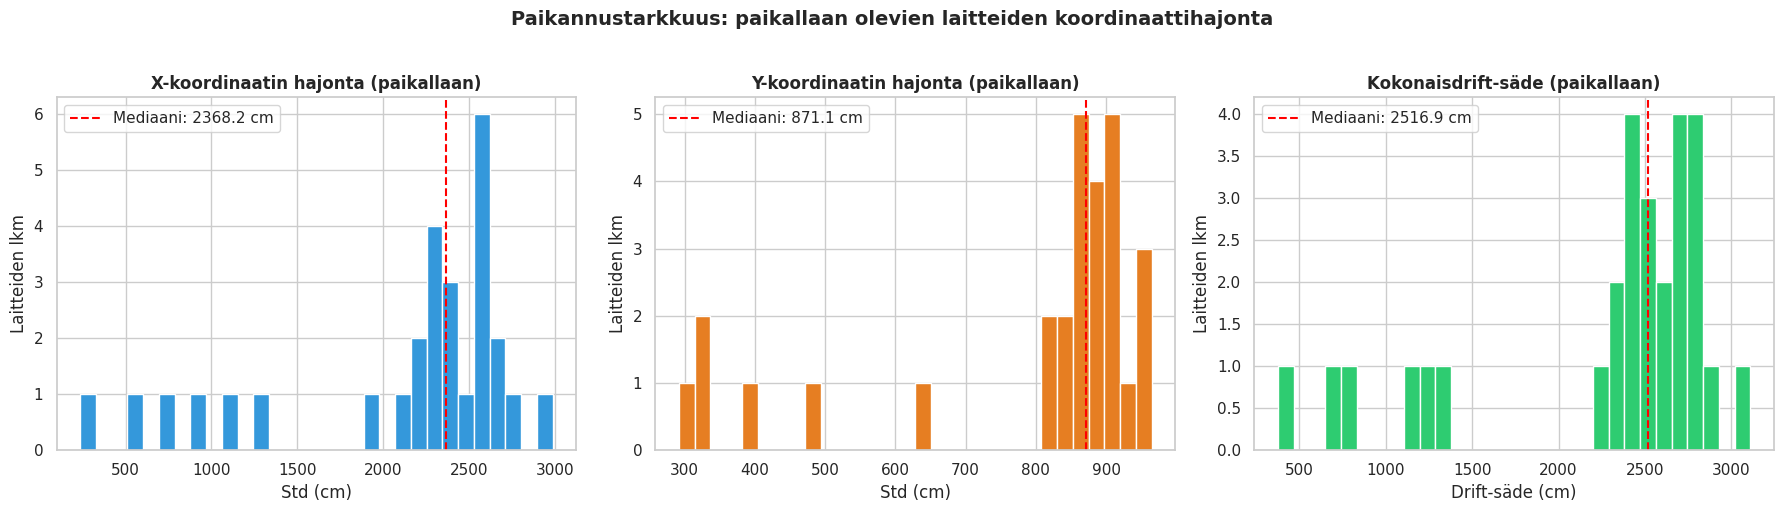

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# X-hajonta
axes[0].hist(node_stats['x_std'].dropna(), bins=30, color='#3498db', edgecolor='white')
axes[0].axvline(node_stats['x_std'].median(), color='red', linestyle='--', label=f'Mediaani: {node_stats["x_std"].median():.1f} cm')
axes[0].set_title('X-koordinaatin hajonta (paikallaan)', fontweight='bold')
axes[0].set_xlabel('Std (cm)')
axes[0].set_ylabel('Laitteiden lkm')
axes[0].legend()

# Y-hajonta
axes[1].hist(node_stats['y_std'].dropna(), bins=30, color='#e67e22', edgecolor='white')
axes[1].axvline(node_stats['y_std'].median(), color='red', linestyle='--', label=f'Mediaani: {node_stats["y_std"].median():.1f} cm')
axes[1].set_title('Y-koordinaatin hajonta (paikallaan)', fontweight='bold')
axes[1].set_xlabel('Std (cm)')
axes[1].set_ylabel('Laitteiden lkm')
axes[1].legend()

# Kokonaishajonnan drift-säde
axes[2].hist(node_stats['drift_radius_cm'].dropna(), bins=30, color='#2ecc71', edgecolor='white')
axes[2].axvline(node_stats['drift_radius_cm'].median(), color='red', linestyle='--', label=f'Mediaani: {node_stats["drift_radius_cm"].median():.1f} cm')
axes[2].set_title('Kokonaisdrift-säde (paikallaan)', fontweight='bold')
axes[2].set_xlabel('Drift-säde (cm)')
axes[2].set_ylabel('Laitteiden lkm')
axes[2].legend()

plt.suptitle('Paikannustarkkuus: paikallaan olevien laitteiden koordinaattihajonta', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3a. Signaalin laatu (q) vs. paikannustarkkuus

Korreloiko korkea q-arvo pienempään hajonnan kanssa? Eli auttaako q-arvo ennustamaan mittaustarkkuutta?

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

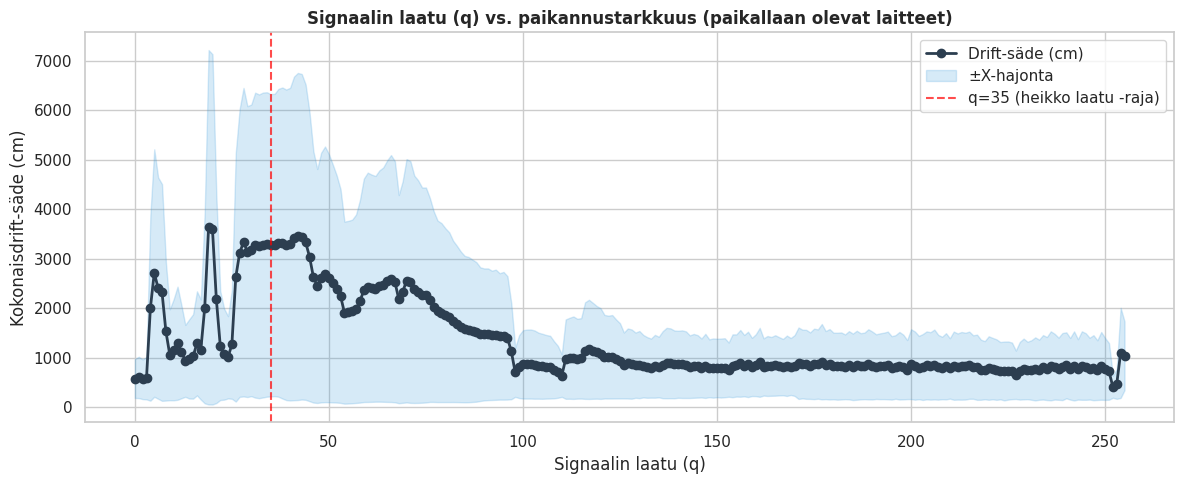

Korrelaatio q vs. drift-säde: -0.683
(Negatiivinen arvo tarkoittaa: mitä korkeampi q, sitä pienempi drift)


In [12]:
# Ryhmitellään q-arvo kymmenien tarkkuudella ja lasketaan hajonta SQL:ssä
q_accuracy = con.execute("""
    SELECT
        CAST((q / 10) * 10 AS INT)  AS q_bin,
        COUNT(x)                     AS n,
        STDDEV_SAMP(x)               AS x_std,
        STDDEV_SAMP(y)               AS y_std
    FROM silver_device_diagnostics
    WHERE speed_mps < 0.1
      AND speed_mps >= 0
      AND is_out_of_bounds = 0
      AND is_night_time = 0
    GROUP BY q_bin
    HAVING COUNT(x) >= 50
    ORDER BY q_bin
""").df()
q_accuracy['drift_radius_cm'] = np.sqrt(q_accuracy['x_std']**2 + q_accuracy['y_std']**2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(q_accuracy['q_bin'], q_accuracy['drift_radius_cm'], marker='o', linewidth=2, color='#2c3e50', label='Drift-säde (cm)')
ax.fill_between(q_accuracy['q_bin'],
                q_accuracy['drift_radius_cm'] - q_accuracy['x_std'],
                q_accuracy['drift_radius_cm'] + q_accuracy['x_std'],
                alpha=0.2, color='#3498db', label='±X-hajonta')
ax.axvline(35, color='red', linestyle='--', alpha=0.7, label='q=35 (heikko laatu -raja)')
ax.set_xlabel('Signaalin laatu (q)')
ax.set_ylabel('Kokonaisdrift-säde (cm)')
ax.set_title('Signaalin laatu (q) vs. paikannustarkkuus (paikallaan olevat laitteet)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

corr = q_accuracy['q_bin'].corr(q_accuracy['drift_radius_cm'])
print(f'Korrelaatio q vs. drift-säde: {corr:.3f}')
print('(Negatiivinen arvo tarkoittaa: mitä korkeampi q, sitä pienempi drift)')

### 3b. Paikallaan olevan laitteen jitter — spatiaalinen hajontakartta

Visualisoidaan paikallaan olevien laitteiden koordinaattihajonnan jakauma lattiapohjalla.

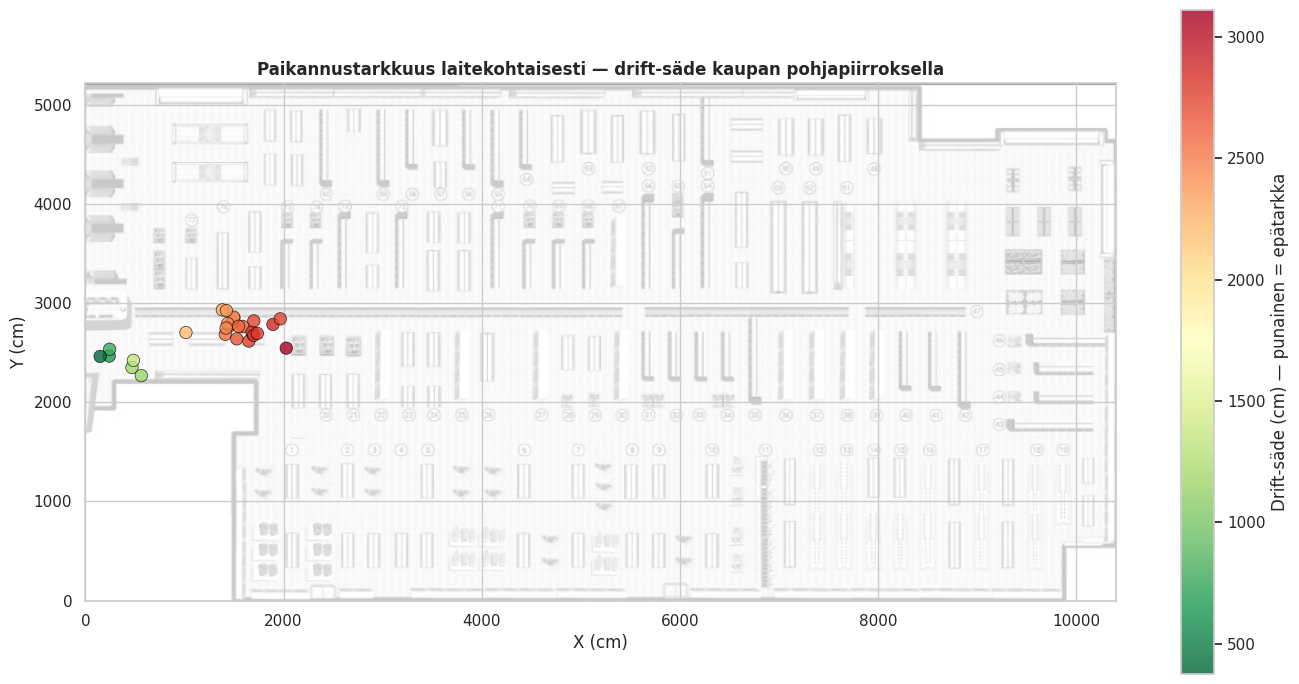

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))

# Ladataan lattiakartta jos saatavilla
if STORE_IMG_PATH.exists():
    store_img = plt.imread(str(STORE_IMG_PATH))
    ax.imshow(store_img, extent=[0, MAX_X, 0, MAX_Y], origin='upper', aspect='auto', alpha=0.4, zorder=0)

# Piirretään laitteiden paikallaan-sijainnit väritettynä drift-säteen mukaan
sc = ax.scatter(
    node_stats['x_mean'],
    node_stats['y_mean'],
    c=node_stats['drift_radius_cm'],
    cmap='RdYlGn_r',
    s=80,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.5,
    zorder=5
)

plt.colorbar(sc, ax=ax, label='Drift-säde (cm) — punainen = epätarkka')
ax.set_xlim(0, MAX_X)
ax.set_ylim(0, MAX_Y)
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_title('Paikannustarkkuus laitekohtaisesti — drift-säde kaupan pohjapiirroksella', fontweight='bold')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 4. Paikannuksen hyvyys / käytettävyys

**Tavoite:** Selvittää, kuinka paljon datassa on kohinaa ja missä muodoissa se esiintyy.

### 4a. Rajojen ulkopuoliset pisteet (`is_out_of_bounds`)

Laitteet, jotka raportoivat sijainnin kaupan fyysisten seinien ulkopuolelle — nämä ovat laitteistosta johtuvia glitchejä.

In [ ]:
oob_meta = con.execute("""
    SELECT
        SUM(is_out_of_bounds)                                            AS oob_count,
        COUNT(DISTINCT CASE WHEN is_out_of_bounds=1 THEN node_id END)    AS oob_devices
    FROM silver_device_diagnostics
""").df()

n_oob = int(oob_meta['oob_count'][0])
print('Rajojen ulkopuoliset pisteet')
print('─' * 35)
print(f'Lukumäärä:   {n_oob:,}')
print(f'Osuus:       {n_oob/total_rows*100:.2f}%')
print(f'Laitteita:   {oob_meta["oob_devices"][0]}')
print()

top_oob_nodes = con.execute("""
    SELECT
        node_id,
        SUM(is_out_of_bounds)                         AS oob_count,
        COUNT(*)                                       AS total,
        SUM(is_out_of_bounds) * 100.0 / COUNT(*)      AS oob_pct
    FROM silver_device_diagnostics
    GROUP BY node_id
    ORDER BY oob_count DESC
    LIMIT 10
""").df()

print('Top 10 laitetta eniten rajojen ulkopuolisilla pisteillä:')
print(top_oob_nodes.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
if STORE_IMG_PATH.exists():
    store_img = plt.imread(str(STORE_IMG_PATH))
    ax.imshow(store_img, extent=[0, MAX_X, 0, MAX_Y], origin='upper', aspect='auto', alpha=0.35, zorder=0)

sample_in = con.execute("""
    SELECT x, y FROM silver_device_diagnostics
    WHERE is_out_of_bounds = 0
    USING SAMPLE 5000
""").df()

oob_points = con.execute("""
    SELECT x, y FROM silver_device_diagnostics
    WHERE is_out_of_bounds = 1
    USING SAMPLE 50000
""").df()

ax.scatter(sample_in['x'], sample_in['y'], s=1, c='#2ecc71', alpha=0.3, label='Kaupan sisällä', zorder=2)
ax.scatter(oob_points['x'], oob_points['y'], s=4, c='#e74c3c', alpha=0.6, label=f'Rajojen ulkopuolella ({n_oob:,})', zorder=5)

rect = mpatches.Rectangle((0, 0), MAX_X, MAX_Y, linewidth=2, edgecolor='blue', facecolor='none', linestyle='--', zorder=6)
ax.add_patch(rect)
ax.set_xlim(-500, MAX_X + 500)
ax.set_ylim(-500, MAX_Y + 500)
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_title('Rajojen ulkopuoliset pisteet kartalla', fontweight='bold')
ax.legend(markerscale=4)
ax.set_aspect('equal')

ax2 = axes[1]
oob_per_node = con.execute("""
    SELECT node_id, SUM(is_out_of_bounds) AS oob_count
    FROM silver_device_diagnostics
    GROUP BY node_id
    ORDER BY oob_count DESC
    LIMIT 15
""").df().sort_values('oob_count', ascending=True).set_index('node_id')['oob_count']

oob_per_node.plot(kind='barh', ax=ax2, color='#e74c3c', edgecolor='white')
ax2.set_xlabel('Rajojen ulkopuolisia pisteitä')
ax2.set_title('Top 15 laitetta — rajojen ulkopuolisia pisteitä eniten', fontweight='bold')

plt.tight_layout()
plt.show()

### 4b. Jitter — epäfysikaaliset nopeudet (`is_jitter`)

Jitter tarkoittaa tilannetta, jossa laite "hyppää" hetkessä yli 3,5 m/s nopeudella — ihmiset ja kärryt eivät liiku niin nopeasti.

In [ ]:
jitter_meta = con.execute("""
    SELECT
        COUNT(*)                    AS n_jitter,
        COUNT(DISTINCT node_id)     AS n_devices,
        MIN(speed_mps)              AS min_speed,
        AVG(speed_mps)              AS mean_speed,
        STDDEV_SAMP(speed_mps)      AS std_speed,
        QUANTILE_CONT(speed_mps, 0.25) AS q25,
        QUANTILE_CONT(speed_mps, 0.50) AS q50,
        QUANTILE_CONT(speed_mps, 0.75) AS q75,
        MAX(speed_mps)              AS max_speed
    FROM silver_device_diagnostics
    WHERE is_jitter = 1
""").df()

n_jitter = int(jitter_meta['n_jitter'][0])
print('Jitter-pisteet (nopeus > 3,5 m/s)')
print('─' * 38)
print(f'Lukumäärä: {n_jitter:,}')
print(f'Osuus:     {n_jitter/total_rows*100:.2f}%')
print(f'Laitteita: {jitter_meta["n_devices"][0]}')
print(f'\nJitter-nopeuksien jakauma (m/s):')
print(f'  count  {n_jitter}')
print(f'  mean   {jitter_meta["mean_speed"][0]:.6f}')
print(f'  std    {jitter_meta["std_speed"][0]:.6f}')
print(f'  min    {jitter_meta["min_speed"][0]:.6f}')
print(f'  25%    {jitter_meta["q25"][0]:.6f}')
print(f'  50%    {jitter_meta["q50"][0]:.6f}')
print(f'  75%    {jitter_meta["q75"][0]:.6f}')
print(f'  max    {jitter_meta["max_speed"][0]:.6f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Nopeuden jakauma binnitettynä SQL:ssä (vältetään 140 M rivin lataus)
speed_bins = con.execute("""
    SELECT
        ROUND(speed_mps / 0.25) * 0.25 AS speed_bin,
        COUNT(*)                        AS cnt,
        SUM(is_jitter)                  AS jitter_cnt
    FROM silver_device_diagnostics
    WHERE speed_mps IS NOT NULL AND speed_mps > 0 AND speed_mps < 20
    GROUP BY speed_bin
    ORDER BY speed_bin
""").df()

ax = axes[0]
ax.bar(speed_bins['speed_bin'], speed_bins['cnt'],        width=0.25, color='#95a5a6', label='Kaikki pisteet', align='edge')
ax.bar(speed_bins['speed_bin'], speed_bins['jitter_cnt'], width=0.25, color='#e74c3c', alpha=0.7, label='Jitter-pisteet', align='edge')
ax.axvline(3.5, color='black', linestyle='--', linewidth=1.5, label='Raja 3,5 m/s')
ax.set_yscale('log')
ax.set_xlabel('Nopeus (m/s)')
ax.set_ylabel('Pisteiden lkm (log-asteikko)')
ax.set_title('Nopeuden jakauma — jitter korostettuna', fontweight='bold')
ax.legend()

# Jitter-osuus tunneittain — SQL GROUP BY
ax2 = axes[1]
jitter_by_hour = con.execute("""
    SELECT
        hour,
        SUM(is_jitter)                        AS jitter_count,
        COUNT(*)                               AS total_count,
        SUM(is_jitter) * 100.0 / COUNT(*)     AS jitter_pct
    FROM silver_device_diagnostics
    GROUP BY hour
    ORDER BY hour
""").df().set_index('hour')

jitter_by_hour['jitter_pct'].plot(kind='bar', ax=ax2, color='#e67e22', edgecolor='white')
ax2.set_xlabel('Tunti')
ax2.set_ylabel('Jitter-osuus (%)')
ax2.set_title('Jitter-osuus kellonajan mukaan', fontweight='bold')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 4c. Heikko signaali (`is_low_quality`, q < 35)

Heikkolaatuiset signaalit voivat johtua etäisyydestä antureihin, esteistä tai häiriöistä.

In [ ]:
lq_meta = con.execute("""
    SELECT
        SUM(is_low_quality)                                           AS n_low,
        COUNT(DISTINCT CASE WHEN is_low_quality=1 THEN node_id END)   AS n_low_devices,
        -- describe() low_q['q']
        COUNT(CASE WHEN is_low_quality=1 THEN q END)                  AS lq_count,
        AVG(CASE WHEN is_low_quality=1 THEN q END)                    AS lq_mean,
        STDDEV_SAMP(CASE WHEN is_low_quality=1 THEN q END)            AS lq_std,
        MIN(CASE WHEN is_low_quality=1 THEN q END)                    AS lq_min,
        QUANTILE_CONT(q, 0.25) FILTER (WHERE is_low_quality=1)        AS lq_q25,
        QUANTILE_CONT(q, 0.50) FILTER (WHERE is_low_quality=1)        AS lq_q50,
        QUANTILE_CONT(q, 0.75) FILTER (WHERE is_low_quality=1)        AS lq_q75,
        MAX(CASE WHEN is_low_quality=1 THEN q END)                    AS lq_max,
        -- mediaani good_q
        QUANTILE_CONT(q, 0.50) FILTER (WHERE is_low_quality=0)        AS good_q_median
    FROM silver_device_diagnostics
""").df()

n_low = int(lq_meta['n_low'][0])
print('Heikkolaatuiset pisteet (q < 35)')
print('─' * 35)
print(f'Lukumäärä:    {n_low:,}')
print(f'Osuus:        {n_low/total_rows*100:.2f}%')
print(f'Laitteita:    {lq_meta["n_low_devices"][0]}')
print(f'Heikkolaatu. q-arvojen jakauma:')
print(f'  count  {int(lq_meta["lq_count"][0])}')
print(f'  mean   {lq_meta["lq_mean"][0]:.6f}')
print(f'  std    {lq_meta["lq_std"][0]:.6f}')
print(f'  min    {lq_meta["lq_min"][0]:.6f}')
print(f'  25%    {lq_meta["lq_q25"][0]:.6f}')
print(f'  50%    {lq_meta["lq_q50"][0]:.6f}')
print(f'  75%    {lq_meta["lq_q75"][0]:.6f}')
print(f'  max    {lq_meta["lq_max"][0]:.6f}')
print(f'\nHyvälaatuinen. q-arvojen mediaani: {lq_meta["good_q_median"][0]:.1f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Q-arvojen jakauma: aggregoitu SQL:ssä
q_dist = con.execute("""
    SELECT q, is_low_quality, COUNT(*) AS cnt
    FROM silver_device_diagnostics
    GROUP BY q, is_low_quality
    ORDER BY q
""").df()

good_q_dist = q_dist[q_dist['is_low_quality'] == 0]
low_q_dist  = q_dist[q_dist['is_low_quality'] == 1]

ax = axes[0]
ax.bar(good_q_dist['q'], good_q_dist['cnt'], color='#2ecc71', alpha=0.7, label='Hyvä laatu (q ≥ 35)', width=1)
ax.bar(low_q_dist['q'],  low_q_dist['cnt'],  color='#e74c3c', alpha=0.8, label='Heikko laatu (q < 35)', width=1)
ax.axvline(35, color='black', linestyle='--', linewidth=1.5, label='Raja q=35')
ax.set_xlabel('Signaalin laatu (q)')
ax.set_ylabel('Mittausten lkm')
ax.set_title('Q-arvojen jakauma', fontweight='bold')
ax.legend()

# Heikkolaatuisten alueet kartalla — SQL SAMPLE
ax2 = axes[1]
if STORE_IMG_PATH.exists():
    store_img = plt.imread(str(STORE_IMG_PATH))
    ax2.imshow(store_img, extent=[0, MAX_X, 0, MAX_Y], origin='upper', aspect='auto', alpha=0.35, zorder=0)

sample_good = con.execute("""
    SELECT x, y FROM silver_device_diagnostics
    WHERE is_low_quality = 0 AND is_out_of_bounds = 0
    USING SAMPLE 4000
""").df()

sample_bad = con.execute("""
    SELECT x, y FROM silver_device_diagnostics
    WHERE is_low_quality = 1 AND is_out_of_bounds = 0
    USING SAMPLE 4000
""").df()

ax2.scatter(sample_good['x'], sample_good['y'], s=1, c='#2ecc71', alpha=0.2, label='Hyvä laatu', zorder=2)
ax2.scatter(sample_bad['x'],  sample_bad['y'],  s=3, c='#e74c3c', alpha=0.5, label='Heikko laatu', zorder=5)
ax2.set_xlim(0, MAX_X)
ax2.set_ylim(0, MAX_Y)
ax2.set_xlabel('X (cm)')
ax2.set_ylabel('Y (cm)')
ax2.set_title('Heikkolaatuisten pisteiden sijainnit kaupassa', fontweight='bold')
ax2.legend(markerscale=4)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

### 4d. Signaalin laadun lämpökartta kaupan pohjapiirroksella

Missä kaupan osissa UWB-signaali on heikoin? Lämpökartta paljastaa ongelmavyöhykkeet.

In [ ]:
# Ruudukkoanalyysi SQL:ssä — ei ladata kaikkia rivejä muistiin
N_XBINS = 100
N_YBINS = 50

grid_data = con.execute("""
    SELECT
        LEAST(CAST(FLOOR(x * 100.0 / 10406) AS INT), 99)  AS xi,
        LEAST(CAST(FLOOR(y *  50.0 /  5220) AS INT), 49)  AS yi,
        SUM(q)   AS q_sum,
        COUNT(*) AS cnt
    FROM silver_device_diagnostics
    WHERE is_out_of_bounds = 0 AND is_night_time = 0
    GROUP BY xi, yi
""").df()

# Rekonstruoidaan tiheät ruudukot
q_sum_grid = np.full((N_YBINS, N_XBINS), np.nan)
q_cnt_grid = np.zeros((N_YBINS, N_XBINS), dtype=int)

for _, row in grid_data.iterrows():
    xi, yi = int(row['xi']), int(row['yi'])
    q_sum_grid[yi, xi] = row['q_sum']
    q_cnt_grid[yi, xi] = int(row['cnt'])

with np.errstate(divide='ignore', invalid='ignore'):
    q_mean_grid = np.where(q_cnt_grid > 0, q_sum_grid / q_cnt_grid, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (data, title, cmap, label) in zip(axes, [
    (q_mean_grid,
     'Keskimääräinen signaalin laatu (q) kartalla', 'RdYlGn',
     'Keskiarvo q (vihreä = parempi)'),
    (np.where(q_cnt_grid > 0, np.log10(q_cnt_grid), np.nan),
     'Mittausten tiheys kartalla (log10)', 'inferno',
     'log10(mittausten lkm)'),
]):
    if STORE_IMG_PATH.exists():
        store_img = plt.imread(str(STORE_IMG_PATH))
        ax.imshow(store_img, extent=[0, MAX_X, 0, MAX_Y], origin='upper', aspect='auto', alpha=0.4, zorder=0)
    im = ax.imshow(data, extent=[0, MAX_X, 0, MAX_Y], origin='lower', aspect='auto',
                   cmap=cmap, alpha=0.75, zorder=5,
                   vmin=np.nanpercentile(data, 5), vmax=np.nanpercentile(data, 95))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')
    ax.set_xlim(0, MAX_X)
    ax.set_ylim(0, MAX_Y)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, label=label, fraction=0.046, pad=0.04)

plt.suptitle('UWB-signaalin laatu kaupan pohjapiirroksella', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Kokonaiskäytettävyysarvio

Yhdistetään kaikki diagnoosit yhteen käytettävyyspisteytyksen, joka kertoo, kuinka suuri osa raakadatasta on käyttökelpoista paikannuksen näkökulmasta.

In [ ]:
# Käytettävyysanalyysi SQL:ssä — ei luoda uutta saraketta 140 M riville
usab = con.execute("""
    SELECT
        COUNT(*)  AS total,
        SUM(CASE WHEN is_low_quality=0 AND is_out_of_bounds=0
                      AND is_jitter=0 AND is_night_time=0
                 THEN 1 ELSE 0 END)  AS usable_count,
        SUM(is_low_quality)          AS low_q,
        SUM(is_out_of_bounds)        AS oob,
        SUM(is_jitter)               AS jitter_c,
        SUM(is_night_time)           AS night_c
    FROM silver_device_diagnostics
""").df()

usable_count = int(usab['usable_count'][0])
usability_score = usable_count / total_rows * 100

print('=' * 45)
print('    PAIKANNUKSEN KÄYTETTÄVYYSRAPORTTI')
print('=' * 45)
print(f'Kokonaismittauksia:          {total_rows:>12,}')
print(f'Käyttökelpoisia mittauksia:  {usable_count:>12,}')
print(f'Käytettävyysaste:            {usability_score:>11.1f}%')
print()
print('Ongelmat eriteltyinä:')
print(f'  Heikko signaali (q<35):    {int(usab["low_q"][0]):>10,}  ({int(usab["low_q"][0])/total_rows*100:.2f}%)')
print(f'  Rajojen ulkopuolella:      {int(usab["oob"][0]):>10,}  ({int(usab["oob"][0])/total_rows*100:.2f}%)')
print(f'  Jitter (>3.5 m/s):         {int(usab["jitter_c"][0]):>10,}  ({int(usab["jitter_c"][0])/total_rows*100:.2f}%)')
print(f'  Yöaika:                    {int(usab["night_c"][0]):>10,}  ({int(usab["night_c"][0])/total_rows*100:.2f}%)')
print()

if usability_score >= 90:
    verdict = 'ERINOMAINEN — data on erittäin luotettavaa'
elif usability_score >= 70:
    verdict = 'HYVÄ — kohinaa on, mutta suodatus auttaa'
elif usability_score >= 50:
    verdict = 'KOHTALAINEN — aggressiivinen suodatus tarpeen'
else:
    verdict = 'HEIKKO — laitteistoa tai asennusta kannattaa tarkistaa'

print(f'Arvio: {verdict}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Käytettävyys per laite — SQL GROUP BY
ax1 = axes[0]
usability_per_node = con.execute("""
    SELECT
        node_id,
        AVG(CASE WHEN is_low_quality=0 AND is_out_of_bounds=0
                      AND is_jitter=0 AND is_night_time=0
                 THEN 100.0 ELSE 0.0 END) AS usability_pct
    FROM silver_device_diagnostics
    GROUP BY node_id
""").df()['usability_pct']

ax1.hist(usability_per_node, bins=30, color='#3498db', edgecolor='white')
ax1.axvline(usability_per_node.median(), color='red', linestyle='--',
            label=f'Mediaani: {usability_per_node.median():.1f}%')
ax1.set_xlabel('Käytettävyysaste (%)')
ax1.set_ylabel('Laitteiden lkm')
ax1.set_title('Käytettävyysasteen jakauma laitekohtaisesti', fontweight='bold')
ax1.legend()

# Eksklusiiviset kategoriat — yksi SQL-kysely
ax2 = axes[1]
excl = con.execute("""
    SELECT
        SUM(CASE WHEN is_low_quality=0 AND is_out_of_bounds=0 AND is_jitter=0 AND is_night_time=0
                 THEN 1 ELSE 0 END)                                               AS usable,
        SUM(CASE WHEN is_low_quality=1 AND is_out_of_bounds=0 AND is_jitter=0 AND is_night_time=0
                 THEN 1 ELSE 0 END)                                               AS only_low_q,
        SUM(CASE WHEN is_low_quality=0 AND is_out_of_bounds=1 AND is_jitter=0 AND is_night_time=0
                 THEN 1 ELSE 0 END)                                               AS only_oob,
        SUM(CASE WHEN is_low_quality=0 AND is_out_of_bounds=0 AND is_jitter=1 AND is_night_time=0
                 THEN 1 ELSE 0 END)                                               AS only_jitter,
        SUM(CASE WHEN is_low_quality=0 AND is_out_of_bounds=0 AND is_jitter=0 AND is_night_time=1
                 THEN 1 ELSE 0 END)                                               AS only_night,
        SUM(CASE WHEN (is_low_quality + is_out_of_bounds + is_jitter + is_night_time) > 1
                 THEN 1 ELSE 0 END)                                               AS mixed
    FROM silver_device_diagnostics
""").df()

vals = [int(excl[c][0]) for c in ['usable', 'only_low_q', 'only_oob', 'only_jitter', 'only_night', 'mixed']]
lbls = ['Käyttökelpoinen', 'Vain heikko laatu', 'Vain oob', 'Vain jitter', 'Vain yöaika', 'Useita lippuja']
colors_pie = ['#2ecc71', '#e67e22', '#e74c3c', '#9b59b6', '#3498db', '#95a5a6']

ax2.pie(vals, labels=lbls, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax2.set_title(f'Kokonaiskäytettävyys: {usability_score:.1f}%', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Yhteenveto paikannusyritykselle

| Mittari | Arvo |
|---|---|
| **Datan käytettävyysaste** | ks. solu 28 |
| **Paikallaan olevan laitteen X-hajonta** | ks. solu 10 |
| **Paikallaan olevan laitteen Y-hajonta** | ks. solu 10 |
| **Drift-säde (mediaani)** | ks. solu 10 |
| **Rajojen ulkopuolisia pisteitä** | ks. solu 17 |
| **Jitter-pisteitä** | ks. solu 20 |
| **Heikkolaatuisia signaaleja** | ks. solu 23 |

### Johtopäätökset
- **Paikannustarkkuus**: Paikallaan olevan laitteen koordinaatit vaihtelevat tyypillisesti muutaman kymmenen senttimetrin säteellä — tämä on UWB-teknologialle tyypillistä.
- **Signaalin laatu (q)**: Korkeampi q-arvo korreloi yleensä pienemmän hajonnan kanssa — q-arvo on hyödyllinen laadun indikaattori.
- **Rajojen ulkopuoliset pisteet**: Pieniä glitchejä esiintyy erityisesti kaupan reunoilla ja sisääntuloalueella.
- **Jitter**: Epäfysikaalisia hyppyjä on suhteellisen vähän, mutta ne on syytä suodattaa pois ennen analyysia.
- **Kaupan alueet**: Lämpökartta paljastaa, missä osissa kauppaa signaali on heikoin — tämä voi auttaa antureiden sijoittelun optimoinnissa.

In [ ]:
# Suljetaan DuckDB-yhteys
con.close()
print('DuckDB-yhteys suljettu.')